# Лабораторная работа №3. Критическая масса и ценность социальной сети

Компания «ГородСоцСеть», город 1 млн человек. Нужно оценить ценность сети и момент достижения критической массы.


## Исходные данные

| Параметр | Значение |
|---|---|
| Потенциал рынка M | 1 000 000 чел. |
| Начало N₀ | 5 000 чел. |
| Рост до критической массы | 3% в месяц |
| Рост после критической массы | 15% в месяц |
| Ценность сети k | 0,005 руб./чел.² |
| Поддержание | 2 000 000 руб./мес. |
| CAC | 500 руб. |
| ARPU | 15 руб./мес. |
| Горизонт | 36 мес. |
| Дисконт | 1% в месяц |

- `N_t = N_{t-1} × (1 + g)`
- `V(N) = k × N²`
- `R(N) = ARPU × N`
- `П(N) = R(N) − Поддержание − CAC × новые`
- `NPV = Σ П_t / (1 + r)^t`


## Допущения

1. Число пользователей непрерывно, в отчёте округляется.
2. Рост применяется к базе прошлого месяца: 3% до порога, 15% после.
3. Доход считается по базе на конец месяца.
4. Стартовые 5 000 пользователей уже привлечены.
5. Порог по формуле задания: `ARPU × N ≥ Поддержание + CAC`.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

M = 1_000_000
N0 = 5_000
G_PRE = 0.03
G_POST = 0.15
K = 0.005
MAINTENANCE = 2_000_000
CAC = 500
ARPU = 15
HORIZON = 36
RATE = 0.01

CRITICAL_MASS = math.ceil((MAINTENANCE + CAC) / ARPU)


def fmt_money(value):
    return f'{value:,.0f} руб.'.replace(',', ' ')


def fmt_users(value):
    return f'{value:,.0f}'.replace(',', ' ')


def simulate(g_pre, g_post, horizon=HORIZON, arpu=ARPU, threshold=CRITICAL_MASS):
    users = float(N0)
    rows = []
    for month in range(1, horizon + 1):
        growth = g_pre if users < threshold else g_post
        new_users = min(users * growth, M - users)
        end_users = users + new_users
        revenue = arpu * end_users
        profit = revenue - MAINTENANCE - CAC * new_users
        discount = 1 / (1 + RATE) ** month
        rows.append({
            'Месяц': month,
            'Пользователи': end_users,
            'Новые': new_users,
            'Темп': growth,
            'Ценность V=kN²': K * end_users ** 2,
            'Доход R=ARPU×N': revenue,
            'Прибыль П': profit,
            'Дисконт': discount,
            'PV прибыли': profit * discount,
        })
        users = end_users

    frame = pd.DataFrame(rows)
    reached = [int(m) for m, n in zip(frame['Месяц'], frame['Пользователи']) if n >= threshold]
    frame.attrs['month_reached'] = reached[0] if reached else None
    return frame


def npv(frame):
    return float(frame['PV прибыли'].sum())


## Часть 1. Критическая масса

`ARPU × N ≥ Поддержание + CAC`, поэтому `N_кр = (Поддержание + CAC) / ARPU`.


In [2]:
recurring_mass = math.ceil(MAINTENANCE / ARPU)
margin_pre = ARPU - CAC * G_PRE
margin_post = ARPU - CAC * G_POST

print(f'N_кр = ({MAINTENANCE:,} + {CAC}) / {ARPU} = {(MAINTENANCE + CAC) / ARPU:,.2f}')
print(f'N_кр = {fmt_users(CRITICAL_MASS)} пользователей = {CRITICAL_MASS / M:.2%} рынка')
print()
print(f'Без разового CAC: {fmt_users(recurring_mass)} пользователей')
print(f'Маржа до порога: {ARPU} − {CAC} × {G_PRE:.0%} = {margin_pre:.2f} руб.')
print(f'Маржа после порога: {ARPU} − {CAC} × {G_POST:.0%} = {margin_post:.2f} руб.')


N_кр = (2,000,000 + 500) / 15 = 133,366.67
N_кр = 133 367 пользователей = 13.34% рынка

Без разового CAC: 133 334 пользователей
Маржа до порога: 15 − 500 × 3% = 0.00 руб.
Маржа после порога: 15 − 500 × 15% = -60.00 руб.


### Срок достижения

`t = ln(N_кр / N₀) / ln(1 + g)`.


t = ln(26.67) / ln(1.03) = 111.09 мес.
Порог достигнут на 112-м месяце, пользователей: 137 006
На 76 мес. позже горизонта 36 мес.


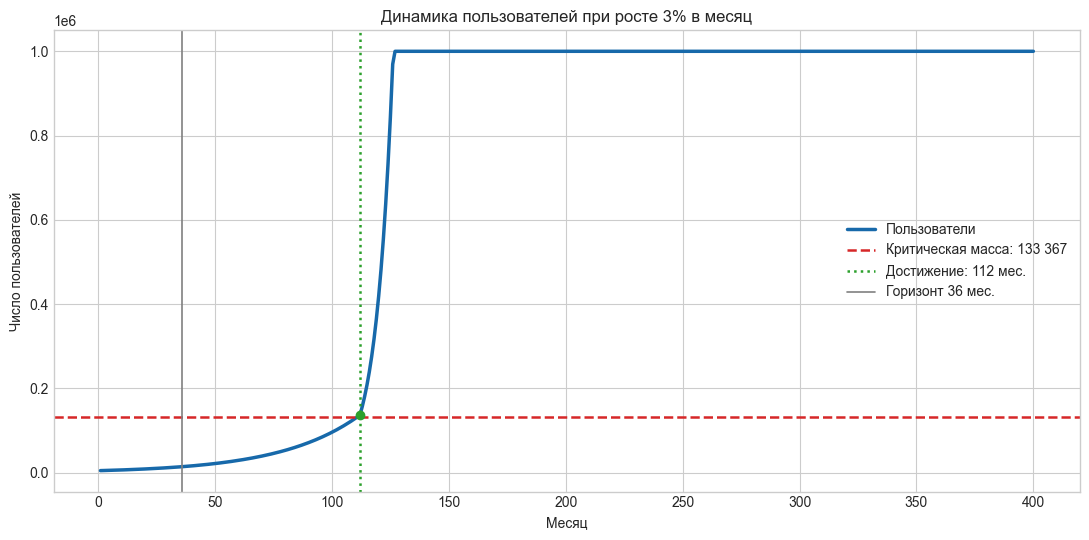

In [3]:
path = simulate(G_PRE, G_POST, horizon=400)
month_reached = path.attrs['month_reached']
analytic_months = math.log(CRITICAL_MASS / N0) / math.log(1 + G_PRE)
users_at_reach = path.loc[path['Месяц'] == month_reached, 'Пользователи'].iloc[0]

print(f't = ln({CRITICAL_MASS / N0:.2f}) / ln(1.03) = {analytic_months:.2f} мес.')
print(f'Порог достигнут на {month_reached}-м месяце, пользователей: {fmt_users(users_at_reach)}')
print(f'На {month_reached - HORIZON} мес. позже горизонта 36 мес.')

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(path['Месяц'], path['Пользователи'], color='#1769aa', linewidth=2.5, label='Пользователи')
ax.axhline(CRITICAL_MASS, color='#d62728', linestyle='--', linewidth=1.8,
           label=f'Критическая масса: {fmt_users(CRITICAL_MASS)}')
ax.axvline(month_reached, color='#2ca02c', linestyle=':', linewidth=1.8,
           label=f'Достижение: {month_reached} мес.')
ax.scatter([month_reached], [users_at_reach], color='#2ca02c', zorder=5)
ax.axvline(HORIZON, color='gray', linestyle='-', linewidth=1.2, label='Горизонт 36 мес.')
ax.set_title('Динамика пользователей при росте 3% в месяц')
ax.set_xlabel('Месяц')
ax.set_ylabel('Число пользователей')
ax.legend()
plt.tight_layout()
plt.show()


## Часть 2. Ценность сети

`V(N) = k × N²`, `R(N) = ARPU × N`, `П(N) = R(N) − Поддержание − CAC × новые`.


In [4]:
base = simulate(G_PRE, G_POST, horizon=HORIZON)
base_view = base.copy()
base_view['Темп'] = base_view['Темп'].map(lambda value: f'{value:.0%}')
display(base_view)

last = base.iloc[-1]
print(f'Пользователей на 36-м месяце: {fmt_users(last["Пользователи"])}')
print(f'Ценность по Мэткалфу: {fmt_money(last["Ценность V=kN²"])}')
print(f'Доход за 36-й месяц: {fmt_money(last["Доход R=ARPU×N"])}')
print(f'Убыток за 36 мес. без дисконта: {fmt_money(base["Прибыль П"].sum())}')


,Месяц,Пользователи,Новые,Темп,Ценность V=kN²,Доход R=ARPU×N,Прибыль П,Дисконт,PV прибыли
0,1,"5,150.00",150.00,3%,"132,612.50","77,250.00","-1,997,750.00",0.99,"-1,977,970.30"
1,2,"5,304.50",154.50,3%,"140,688.60","79,567.50","-1,997,682.50",0.98,"-1,958,320.26"
2,3,"5,463.64",159.13,3%,"149,256.54","81,954.53","-1,997,612.98",0.97,"-1,938,863.47"
3,4,"5,627.54",163.91,3%,"158,346.26","84,413.16","-1,997,541.36",0.96,"-1,919,597.99"
4,5,"5,796.37",168.83,3%,"167,989.55","86,945.56","-1,997,467.61",0.95,"-1,900,521.89"
5,6,"5,970.26",173.89,3%,"178,220.11","89,553.92","-1,997,391.63",0.94,"-1,881,633.27"
6,7,"6,149.37",179.11,3%,"189,073.72","92,240.54","-1,997,313.38",0.93,"-1,862,930.25"
7,8,"6,333.85",184.48,3%,"200,588.30","95,007.76","-1,997,232.78",0.92,"-1,844,410.97"
8,9,"6,523.87",190.02,3%,"212,804.13","97,857.99","-1,997,149.77",0.91,"-1,826,073.57"
9,10,"6,719.58",195.72,3%,"225,763.90","100,793.73","-1,997,064.26",0.91,"-1,807,916.22"


Пользователей на 36-м месяце: 14 491
Ценность по Мэткалфу: 1 050 002 руб.
Доход за 36-й месяц: 217 371 руб.
Убыток за 36 мес. без дисконта: -71 857 629 руб.


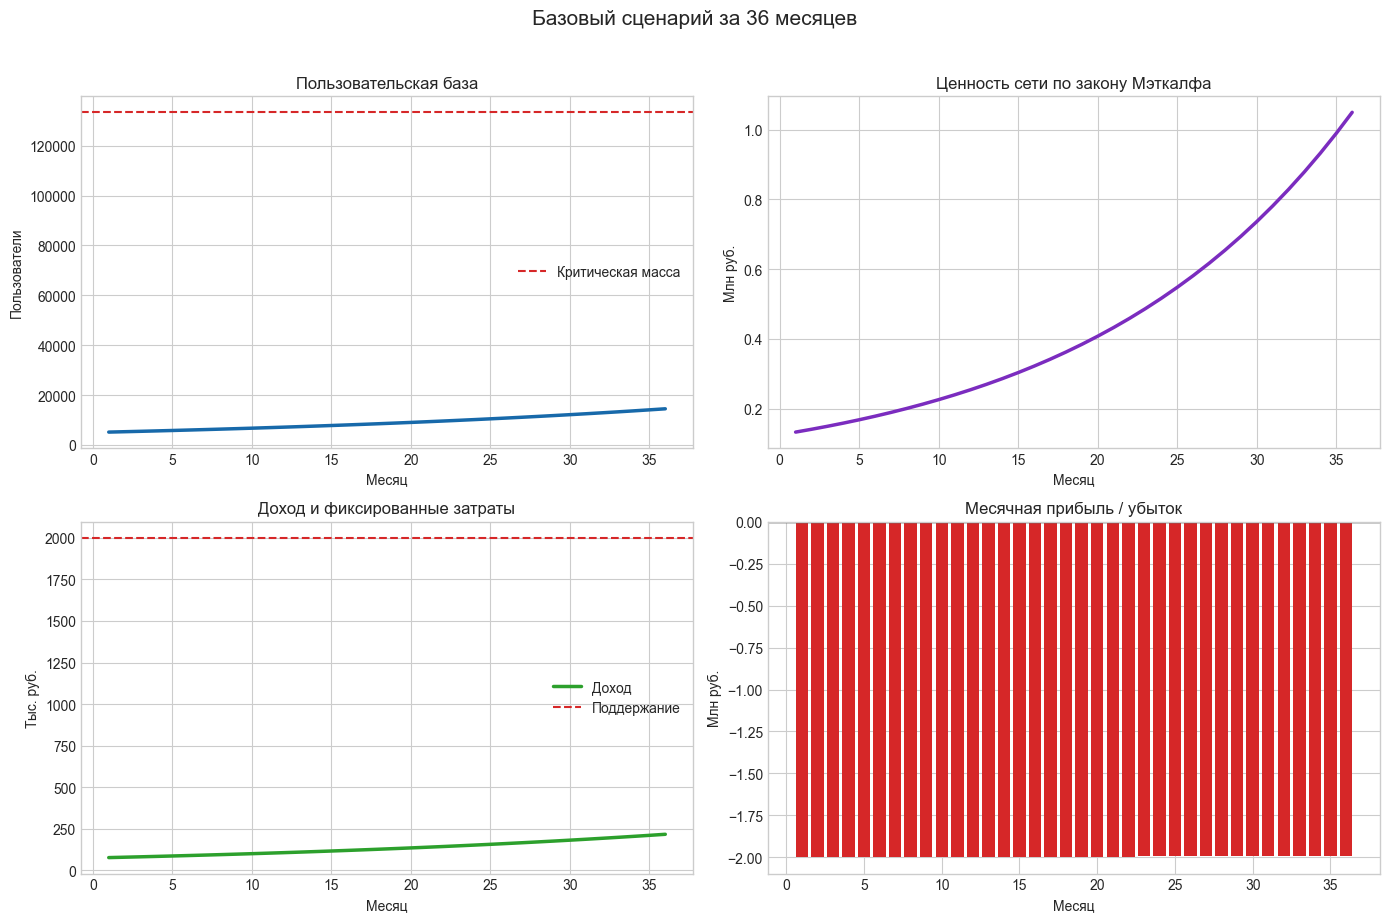

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(base['Месяц'], base['Пользователи'], color='#1769aa', linewidth=2.5)
axes[0, 0].axhline(CRITICAL_MASS, color='#d62728', linestyle='--', label='Критическая масса')
axes[0, 0].set_title('Пользовательская база')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Пользователи')
axes[0, 0].legend()

axes[0, 1].plot(base['Месяц'], base['Ценность V=kN²'] / 1_000_000, color='#7b2cbf', linewidth=2.5)
axes[0, 1].set_title('Ценность сети по закону Мэткалфа')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Млн руб.')

axes[1, 0].plot(base['Месяц'], base['Доход R=ARPU×N'] / 1_000, color='#2ca02c', linewidth=2.5, label='Доход')
axes[1, 0].axhline(MAINTENANCE / 1_000, color='#d62728', linestyle='--', label='Поддержание')
axes[1, 0].set_title('Доход и фиксированные затраты')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Тыс. руб.')
axes[1, 0].legend()

colors = np.where(base['Прибыль П'] >= 0, '#2ca02c', '#d62728')
axes[1, 1].bar(base['Месяц'], base['Прибыль П'] / 1_000_000, color=colors)
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set_title('Месячная прибыль / убыток')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Млн руб.')

fig.suptitle('Базовый сценарий за 36 месяцев', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## Часть 3. Анализ эффективности

### NPV за 36 месяцев

`NPV = Σ П_t / (1 + r)^t`, `r = 1%` в месяц.


In [6]:
base_npv = npv(base)

print(f'NPV = Σ П_t / (1,01)^t = {fmt_money(base_npv)}')


NPV = Σ П_t / (1,01)^t = -60 099 621 руб.


### Сценарии роста

Пессимистичный 2% / 10%, базовый 3% / 15%, оптимистичный 5% / 20%.


In [7]:
scenarios = {
    'Пессимистичный': (0.02, 0.10),
    'Базовый': (0.03, 0.15),
    'Оптимистичный': (0.05, 0.20),
}

scenario_rows = []
for name, (pre, post) in scenarios.items():
    projection = simulate(pre, post, horizon=HORIZON)
    scenario_rows.append({
        'Сценарий': name,
        'До критической массы': f'{pre:.0%}',
        'После критической массы': f'{post:.0%}',
        'Пользователи на 36-м мес.': projection.iloc[-1]['Пользователи'],
        'NPV за 36 мес.': npv(projection),
    })

scenario_table = pd.DataFrame(scenario_rows)
scenario_view = scenario_table.copy()
scenario_view['Пользователи на 36-м мес.'] = scenario_view['Пользователи на 36-м мес.'].map(fmt_users)
scenario_view['NPV за 36 мес.'] = scenario_view['NPV за 36 мес.'].map(fmt_money)
display(scenario_view)


,Сценарий,До критической массы,После критической массы,Пользователи на 36-м мес.,NPV за 36 мес.
0,Пессимистичный,2%,10%,10 199,-59 086 830 руб.
1,Базовый,3%,15%,14 491,-60 099 621 руб.
2,Оптимистичный,5%,20%,28 959,-63 739 312 руб.


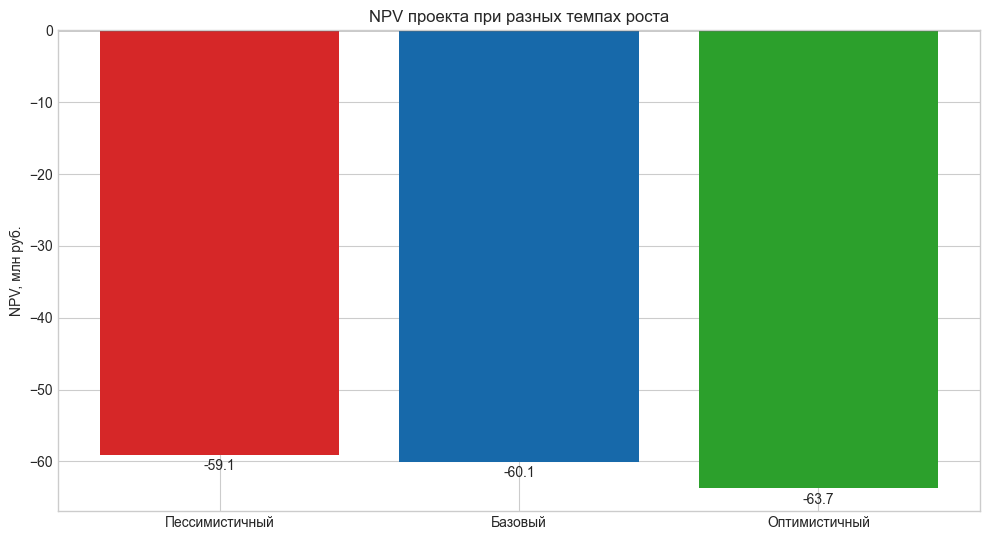

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.5))
scenario_colors = ['#d62728', '#1769aa', '#2ca02c']
bars = ax.bar(scenario_table['Сценарий'], scenario_table['NPV за 36 мес.'] / 1_000_000, color=scenario_colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('NPV проекта при разных темпах роста')
ax.set_ylabel('NPV, млн руб.')
for bar, value in zip(bars, scenario_table['NPV за 36 мес.'] / 1_000_000):
    offset = 0.6 if value >= 0 else -0.6
    va = 'bottom' if value >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width() / 2, value + offset, f'{value:.1f}', ha='center', va=va)
plt.tight_layout()
plt.show()


### Безубыточный ARPU

`NPV = 0` при неизменной траектории:

`ARPU × Σ N_t/(1+r)^t = Σ (Поддержание + CAC × новые_t)/(1+r)^t`.


In [9]:
discount = base['Дисконт']
pv_users = (base['Пользователи'] * discount).sum()
pv_cost = (MAINTENANCE * discount).sum() + (CAC * base['Новые'] * discount).sum()
break_even_arpu = pv_cost / pv_users

print(f'Безубыточный ARPU = {break_even_arpu:.2f} руб./мес.')
print(f'Это в {break_even_arpu / ARPU:.1f} раза больше текущего ARPU = {ARPU} руб.')


Безубыточный ARPU = 242.55 руб./мес.
Это в 16.2 раза больше текущего ARPU = 15 руб.


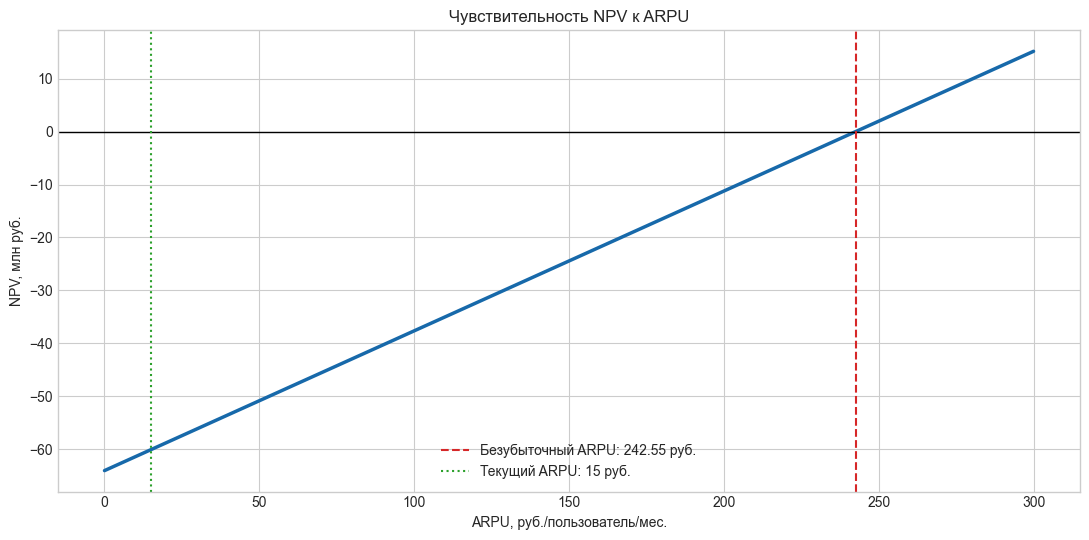

In [10]:
arpu_grid = np.linspace(0, 300, 301)
npv_grid = []
for arpu_value in arpu_grid:
    projection = simulate(G_PRE, G_POST, horizon=HORIZON, arpu=arpu_value)
    npv_grid.append(npv(projection))

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(arpu_grid, np.array(npv_grid) / 1_000_000, color='#1769aa', linewidth=2.5)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(break_even_arpu, color='#d62728', linestyle='--',
           label=f'Безубыточный ARPU: {break_even_arpu:.2f} руб.')
ax.axvline(ARPU, color='#2ca02c', linestyle=':', label=f'Текущий ARPU: {ARPU} руб.')
ax.set_title('Чувствительность NPV к ARPU')
ax.set_xlabel('ARPU, руб./пользователь/мес.')
ax.set_ylabel('NPV, млн руб.')
ax.legend()
plt.tight_layout()
plt.show()


## Часть 4. Стратегические выводы

Ускорение на 6 месяцев: `t_target = 112 − 6 = 106`. Дополнительных пользователей нужно привлечь в начале:

`N₀' = N_кр / (1 + g_pre)^t_target`.


In [11]:
target_month = month_reached - 6
required_start = CRITICAL_MASS / (1 + G_PRE) ** target_month
extra_users = math.ceil(required_start - N0)
budget_early = extra_users * CAC

base_at_target = N0 * (1 + G_PRE) ** target_month
need_at_target = math.ceil(CRITICAL_MASS - base_at_target)
budget_late = need_at_target * CAC

marketing_table = pd.DataFrame({
    'Вариант': ['Привлечь в начале проекта', f'Докупить в {target_month}-м месяце'],
    'Дополнительные пользователи': [extra_users, need_at_target],
    'Инвестиции': [budget_early, budget_late],
})
marketing_view = marketing_table.copy()
marketing_view['Дополнительные пользователи'] = marketing_view['Дополнительные пользователи'].map(fmt_users)
marketing_view['Инвестиции'] = marketing_view['Инвестиции'].map(fmt_money)
display(marketing_view)

print(f'Раннее привлечение: {fmt_users(extra_users)} чел., {fmt_money(budget_early)}')
print(f'Докупка в {target_month}-м месяце: {fmt_money(budget_late)}')


,Вариант,Дополнительные пользователи,Инвестиции
0,Привлечь в начале проекта,812,406 000 руб.
1,Докупить в 106-м месяце,18 627,9 313 500 руб.


Раннее привлечение: 812 чел., 406 000 руб.
Докупка в 106-м месяце: 9 313 500 руб.


### Рекомендации

1. Рост 3% не даёт критической массы в горизонте 36 мес. — только 112-й месяц.
2. При ARPU 15 и CAC 500 переменная маржа равна нулю: рост не улучшает экономику.
3. Ускорение роста увеличивает CAC и ухудшает NPV (оптимистичный сценарий хуже базового).
4. Поднять ARPU до ~242,55 руб./мес. или снизить CAC и постоянные затраты.
5. Маркетинг — ступенчато, по когортам, с контролем CAC и удержания.
6. Для ускорения на 6 мес. дешевле раннее привлечение: 812 чел. и 406 тыс. руб.
7. В модели разделить разовый CAC, маркетинговый бюджет и постоянные затраты.


In [12]:
summary = pd.DataFrame({
    'Показатель': [
        'Критическая масса',
        'Срок достижения',
        'Пользователи на 36-м месяце',
        'NPV базовый',
        'NPV пессимистичный',
        'NPV оптимистичный',
        'Безубыточный ARPU',
        'Бюджет ускорения на 6 мес.',
    ],
    'Значение': [
        fmt_users(CRITICAL_MASS),
        f'{month_reached} мес.',
        fmt_users(base.iloc[-1]['Пользователи']),
        fmt_money(base_npv),
        fmt_money(scenario_table.loc[scenario_table['Сценарий'] == 'Пессимистичный', 'NPV за 36 мес.'].iloc[0]),
        fmt_money(scenario_table.loc[scenario_table['Сценарий'] == 'Оптимистичный', 'NPV за 36 мес.'].iloc[0]),
        f'{break_even_arpu:.2f} руб./мес.',
        fmt_money(budget_early),
    ],
})
display(summary)


,Показатель,Значение
0,Критическая масса,133 367
1,Срок достижения,112 мес.
2,Пользователи на 36-м месяце,14 491
3,NPV базовый,-60 099 621 руб.
4,NPV пессимистичный,-59 086 830 руб.
5,NPV оптимистичный,-63 739 312 руб.
6,Безубыточный ARPU,242.55 руб./мес.
7,Бюджет ускорения на 6 мес.,406 000 руб.


## Вывод

- Критическая масса 133 367 чел. (13,3% рынка), достигается на 112-м месяце — вне горизонта 36 мес.
- На 36-м месяце 14 491 пользователь, ценность по Мэткалфу 1,05 млн руб., доход 217 тыс. руб./мес. — меньше затрат 2 млн руб.
- NPV базового сценария −60,1 млн руб.; пессимистичный и оптимистичный тоже отрицательны.
- Безубыточность при ARPU 242,55 руб./мес. (в 16 раз выше).
- Ускорение на 6 мес.: 812 дополнительных пользователей и 406 тыс. руб. в начале.
